# Module 3 — Data Cleaning
### Real-time payment fraud detection for an e-commerce platform

**Input:** `data/processed/transactions_enriched.parquet` (Module 1 output)
**Outputs:**
- `data/processed/transactions_cleaned.parquet` — the cleaned dataset
- `Module_08/cleaning_decisions.md` + CSV summaries — the documented decisions
- figures in `figures/`

This notebook does five things the rubric asks for — handle missing values,
duplicates, and inconsistent categories; treat outliers / implausible values and
invalid timestamps; and **document every decision with before/after comparisons** —
plus the one substantive PaySim data-quality item the EDA surfaced: the
**balance-reconciliation convention**.

Two deliberate design choices, stated up front:

1. **Cleaning ≠ feature engineering.** The cleaned file carries the same columns
   as the enriched file, standardised and validated. Derived quantities (balance
   errors, log-amount, merchant flags) are *documented* here but **engineered in
   Module 4**, so the two stages stay auditable and separate.
2. **Document-and-retain over silent deletion.** PaySim is a simulated log with
   known conventions (e.g. masked destination balances). Where a value is a
   convention or a plausible tail rather than corruption, we **flag and keep it**,
   recording the reasoning, rather than dropping rows and distorting the fraud
   signal.

> Assumes the enriched parquet exists (run `scripts/generate_synthetic.py` first).

## Setup

Bootstrap the repo root so `scripts.config` imports from anywhere, pull all paths
from config, and define small helpers that (a) save a figure to `figures/` and
(b) write a table/markdown artefact to `Module_08/` — mirroring the EDA notebook.

In [12]:
import sys
from pathlib import Path

def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "scripts" / "config.py").exists():
            return cand
    return p
ROOT_GUESS = _find_root(Path.cwd())
if str(ROOT_GUESS) not in sys.path:
    sys.path.insert(0, str(ROOT_GUESS))

from scripts.config import (ROOT, ENRICHED_DATA_PATH, DATA_PROCESSED, FIGURES,
                            COUNTRIES)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

# output locations
REPORTS = ROOT / "Module_08"           # tables + decisions log land here
CLEANED_DATA_PATH = DATA_PROCESSED / "transactions_cleaned.parquet"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    p = FIGURES / f"{name}.png"; fig.savefig(p); print(f"figure -> {p.relative_to(ROOT)}")

def save_table(df, name, index=True):
    p = REPORTS / f"{name}.csv"; df.to_csv(p, index=index); print(f"table  -> {p.relative_to(ROOT)}")

# vocab / ranges we validate against (from config + the data dictionary)
ALLOWED_TYPES = {"CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"}
ALLOWED_COUNTRIES = set(COUNTRIES)
BINARY_COLUMNS = ["isFraud", "isFlaggedFraud", "is_new_device",
                  "shipping_billing_mismatch", "is_night"]
print("Config loaded. Outputs ->", REPORTS.relative_to(ROOT))

Config loaded. Outputs -> Module_08


## Load the enriched data & snapshot "before" metrics

We capture a `before` snapshot now so every later step can be reported as a true
before/after comparison — the core documentation requirement of this module.

In [13]:
assert ENRICHED_DATA_PATH.exists(), (
    f"Enriched parquet not found: {ENRICHED_DATA_PATH} — run scripts/generate_synthetic.py")
df = pd.read_parquet(ENRICHED_DATA_PATH)
clean = df.copy()   # we mutate `clean`; `df` stays as the untouched 'before'

before = {
    "rows": len(df),
    "columns": df.shape[1],
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "fraud_count": int(df.isFraud.sum()),
    "fraud_rate_%": round(df.isFraud.mean() * 100, 4),
}
print("BEFORE:", before)

BEFORE: {'rows': 6362620, 'columns': 23, 'missing_cells': 0, 'duplicate_rows': 0, 'fraud_count': 8213, 'fraud_rate_%': np.float64(0.1291)}


## 1. Schema & required-column validation

**Reasoning.** Cleaning starts by asserting the contract: the exact columns the
downstream modules expect must be present, so a malformed upstream file fails loud
and early rather than silently producing wrong features.

**What to look for.** No missing required columns; dtypes broadly sensible
(numerics numeric, ids as strings, labels 0/1).

**Business tie-in.** In a real pipeline this is the schema gate before scoring —
a contract violation should stop the run, not reach the model.

In [14]:
REQUIRED = ["step","type","amount","nameOrig","oldbalanceOrg","newbalanceOrig",
            "nameDest","oldbalanceDest","newbalanceDest","isFraud","isFlaggedFraud",
            "account_age_days","home_billing_country","home_device_id","device_id",
            "is_new_device","browser_fingerprint","shipping_billing_mismatch",
            "failed_payment_attempts","ip_country","ip_billing_distance_km",
            "hour_of_day","is_night"]
missing = [c for c in REQUIRED if c not in clean.columns]
assert not missing, f"Missing required columns: {missing}"
print(f"all {len(REQUIRED)} required columns present")
pd.DataFrame({"dtype": clean.dtypes.astype(str)})

all 23 required columns present


,dtype
step,int64
type,str
amount,float64
nameOrig,str
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,str
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


## 2. Missing values

**Reasoning.** We check for nulls and decide a policy *before* touching anything.
PaySim itself has no missing values, but coercions later can introduce them, so we
establish the rule now: any residual null in a required field is handled explicitly
(not left to silently propagate).

**What to look for.** A per-column null count (expected all-zero on PaySim). Our
policy: numeric nulls that appear after coercion are treated as invalid and
dropped with a logged count; we do **not** silently impute financial fields.

**Business tie-in.** Imputing a balance or amount would fabricate money movement.
For a risk model it's safer to drop an unparseable record than invent its value.

In [15]:
null_counts = clean.isna().sum()
null_counts = null_counts[null_counts > 0]
if null_counts.empty:
    print("no missing values present")
else:
    display(null_counts.to_frame("n_missing"))
save_table(clean.isna().sum().to_frame("n_missing"), "missing_by_column")

no missing values present
table  -> Module_08/missing_by_column.csv


## 3. Duplicate rows

**Reasoning.** Exact duplicate rows can bias both training and EDA summaries, so we
remove full-row duplicates. Note that in PaySim, per-transaction ids and the
generated device/fingerprint make genuine duplicates essentially impossible — so
we expect this to remove ~nothing, and we report it honestly rather than implying
work that didn't happen.

**What to look for.** A duplicate count at or near zero; row count essentially
unchanged.

**Business tie-in.** In production, dedup guards against double-ingested events
(e.g. a webhook delivered twice) inflating a customer's apparent activity.

In [16]:
dups = int(clean.duplicated().sum())
clean = clean.drop_duplicates().reset_index(drop=True)
print(f"duplicate rows removed: {dups}  ->  rows now: {len(clean):,}")

duplicate rows removed: 0  ->  rows now: 6,362,620


## 4. Inconsistent categories → standardise & validate against vocabulary

**Reasoning.** Categorical fields (`type`, `home_billing_country`, `ip_country`)
must be normalised (trim + upper-case) so `"us"`, `" US "` and `"US"` don't become
three categories, then **validated against the known vocabulary**. Standardising
without validating (the gap in the earlier draft) leaves out-of-vocab values
undetected.

**What to look for.** After normalisation, every `type` is one of the five PaySim
types and every country is one of the ten in `config.COUNTRIES`. Any out-of-vocab
value is surfaced, not swallowed.

**Business tie-in.** A stray country code or mis-cased type would silently break
one-hot encoding in Module 4 and could route real transactions to the wrong risk
bucket.

In [17]:
for col in ["type", "home_billing_country", "ip_country"]:
    clean[col] = clean[col].astype(str).str.strip().str.upper()

bad_types = set(clean.type.unique()) - ALLOWED_TYPES
bad_home  = set(clean.home_billing_country.unique()) - ALLOWED_COUNTRIES
bad_ip    = set(clean.ip_country.unique()) - ALLOWED_COUNTRIES
print("out-of-vocab type values      :", bad_types or "none")
print("out-of-vocab home_country     :", bad_home or "none")
print("out-of-vocab ip_country       :", bad_ip or "none")
# policy: no out-of-vocab values expected; if any appear they are logged for review
assert not (bad_types or bad_home or bad_ip), "Out-of-vocabulary categories found — review before proceeding"
print("all categorical values within the expected vocabulary")

out-of-vocab type values      : none
out-of-vocab home_country     : none
out-of-vocab ip_country       : none
all categorical values within the expected vocabulary


## 5. Range & validity checks (both bounds, against the data dictionary)

**Reasoning.** Every field has a documented valid range in `data_dictionary.md`.
We validate **both** bounds for each (the earlier draft only checked lower bounds),
including the invalid-timestamp check the rubric names explicitly (`step` within
1–743, `hour_of_day` within 0–23), and binary fields strictly in {0,1}.

**What to look for.** A pass/fail table. The generator clips most fields, so most
checks pass by construction — the point is to *verify and document* that, and to
catch anything that slips (e.g. rare `ip_billing_distance_km` values just past the
approximate ceiling, which are legitimate exponential-tail draws, not corruption).

**Business tie-in.** Explicit range contracts are what later let a monitoring job
(Module 7) assert incoming data looks like training data; violations become drift
alarms rather than silent model degradation.

In [18]:
checks = [
    ("step",                    1,    743),
    ("hour_of_day",             0,     23),
    ("account_age_days",        1,   3650),
    ("failed_payment_attempts", 0,     12),
    ("ip_billing_distance_km",  0,  23000),
    ("amount",                  0,   np.inf),
]
rows = []
for col, lo, hi in checks:
    below = int((clean[col] < lo).sum())
    above = int((clean[col] > hi).sum())
    rows.append({"column": col, "min_allowed": lo, "max_allowed": hi,
                 "n_below": below, "n_above": above,
                 "observed_min": clean[col].min(), "observed_max": clean[col].max()})
for col in BINARY_COLUMNS:
    bad = int((~clean[col].isin([0, 1])).sum())
    rows.append({"column": col, "min_allowed": 0, "max_allowed": 1,
                 "n_below": bad, "n_above": 0,
                 "observed_min": clean[col].min(), "observed_max": clean[col].max()})
validity = pd.DataFrame(rows).set_index("column")
display(validity)
save_table(validity, "validity_checks")

# ip distance just past the approximate ~23000 ceiling: keep (plausible tail), document
n_tail = int((clean.ip_billing_distance_km > 23000).sum())
print(f"\nip_billing_distance_km > 23000 (approx ceiling): {n_tail} rows "
      f"-> retained as legitimate exponential-tail draws (documented, not dropped)")

,min_allowed,max_allowed,n_below,n_above,observed_min,observed_max
column,,,,,,
step,1,743.0,0,0,1.0,743.00
hour_of_day,0,23.0,0,0,0.0,23.00
account_age_days,1,3650.0,0,0,1.0,3360.00
failed_payment_attempts,0,12.0,0,0,0.0,11.00
ip_billing_distance_km,0,23000.0,0,49,0.0,36738.40
amount,0,inf,0,0,0.0,92445516.64
isFraud,0,1.0,0,0,0.0,1.00
isFlaggedFraud,0,1.0,0,0,0.0,1.00
is_new_device,0,1.0,0,0,0.0,1.00


table  -> Module_08/validity_checks.csv

ip_billing_distance_km > 23000 (approx ceiling): 49 rows -> retained as legitimate exponential-tail draws (documented, not dropped)


## 6. Amount checks — negative and zero

**Reasoning.** Negative amounts are invalid for payments and would be removed if
present (none exist in PaySim, so this is a guard, reported as such). Zero-amount
rows do occur; rather than delete them we keep and **note** them, since a zero can
be a system/rule artefact and deleting without evidence would drop potential signal.

**What to look for.** Zero negative-amount rows (guard passes trivially); a small
count of zero-amount rows, retained.

**Business tie-in.** Over-aggressive amount filtering throws away edge cases that
can carry fraud signal (card-testing often uses tiny or zero authorisations).

In [19]:
neg = int((clean.amount < 0).sum())
zero = int((clean.amount == 0).sum())
clean = clean[clean.amount >= 0].reset_index(drop=True)
print(f"negative-amount rows removed : {neg}")
print(f"zero-amount rows retained    : {zero}  (kept, flagged for review in FE)")

negative-amount rows removed : 0
zero-amount rows retained    : 16  (kept, flagged for review in FE)


## 7. Balance-reconciliation convention (the real PaySim quirk)

**Reasoning.** This is the substantive data-quality item the EDA flagged and the
earlier draft omitted entirely. In PaySim the ledger frequently does **not**
reconcile — `oldbalanceOrg − amount ≠ newbalanceOrig` — and a large share of
destination accounts carry both balances at zero (a masking/unknown convention,
concentrated on merchant destinations). We **quantify and document** this, and
**retain** the rows: it is how PaySim represents reality, and the mismatch itself
is predictive.

**What to look for.** A high fraction of non-reconciling rows on both origin and
destination sides, and a large block of all-zero destination balances. Crucially
we do **not** "correct" these — that would destroy signal and misrepresent the
source.

**Business tie-in.** The reconciliation gap and zero-balance masking are exactly
the kind of thing Module 4 turns into features and Module 8 might turn into a
review rule. Documenting the convention here prevents a later analyst from
mistaking it for corruption and "fixing" it.

*(These error terms are computed for documentation only — they are engineered as
features in Module 4, not written into the cleaned file.)*

,pct_of_rows
metric,
orig not reconciling,80.6
dest not reconciling,68.6
dest balances both zero (masked),36.4


table  -> Module_08/balance_reconciliation.csv
figure -> Module_08/figures/m3_01_masked_dest_balances.png


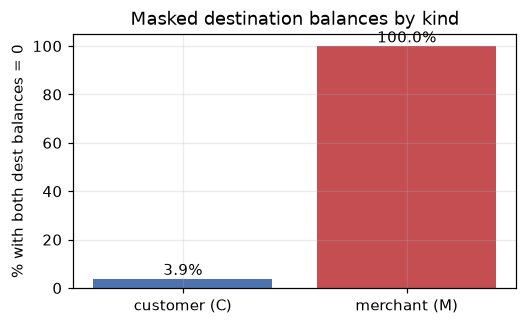

In [20]:
orig_err = clean.oldbalanceOrg - clean.amount - clean.newbalanceOrig
dest_err = clean.oldbalanceDest + clean.amount - clean.newbalanceDest
masked_dest = (clean.oldbalanceDest == 0) & (clean.newbalanceDest == 0)

recon = pd.DataFrame({
    "metric": ["orig not reconciling", "dest not reconciling",
               "dest balances both zero (masked)"],
    "pct_of_rows": [
        round((~np.isclose(orig_err, 0)).mean() * 100, 1),
        round((~np.isclose(dest_err, 0)).mean() * 100, 1),
        round(masked_dest.mean() * 100, 1),
    ],
}).set_index("metric")
display(recon)
save_table(recon, "balance_reconciliation")

# document how the masking splits by destination kind (merchant vs customer)
by_dest = clean.assign(dest_kind=np.where(clean.nameDest.str.startswith("M"),
                                          "merchant (M)", "customer (C)"),
                       masked=masked_dest.astype(int))
split = by_dest.groupby("dest_kind")["masked"].mean().mul(100).round(1)

fig, ax = plt.subplots(figsize=(5.2, 3))
ax.bar(split.index, split.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("% with both dest balances = 0"); ax.set_title("Masked destination balances by kind")
for i, v in enumerate(split.values): ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
save_fig(fig, "m3_01_masked_dest_balances"); plt.show()

## 8. Finalise — before/after summary, write cleaned data & decisions log

**Reasoning.** We snapshot the `after` metrics, present them beside `before` as the
required comparison, then persist the cleaned parquet and write the decisions log
and CSV summaries to `Module_08/`.

**What to look for.** Row/fraud counts essentially unchanged (PaySim is clean, so
honest cleaning is mostly *validation + documentation*); the notable, documented
finding is the balance convention, not mass row removal.

**Business tie-in.** The deliverable is a *defensible* dataset: every transform is
logged with a reason, so a reviewer (or auditor) can trace exactly what happened to
the data before it reached the model.

In [21]:
after = {
    "rows": len(clean),
    "columns": clean.shape[1],
    "missing_cells": int(clean.isna().sum().sum()),
    "duplicate_rows": int(clean.duplicated().sum()),
    "fraud_count": int(clean.isFraud.sum()),
    "fraud_rate_%": round(clean.isFraud.mean() * 100, 4),
}
summary = pd.DataFrame({"before": before, "after": after})
summary["changed"] = summary["before"] != summary["after"]
display(summary)
save_table(summary, "before_after_summary")

# persist cleaned data (same columns as enriched: cleaning != feature engineering)
assert list(clean.columns) == list(df.columns), "column set changed — keep cleaning separate from FE"
clean.to_parquet(CLEANED_DATA_PATH, index=False)
print(f"\ncleaned data -> {CLEANED_DATA_PATH.relative_to(ROOT)}  shape={clean.shape}")

,before,after,changed
rows,6.362620e+06,6.362620e+06,False
columns,2.300000e+01,2.300000e+01,False
missing_cells,0.000000e+00,0.000000e+00,False
duplicate_rows,0.000000e+00,0.000000e+00,False
fraud_count,8.213000e+03,8.213000e+03,False
fraud_rate_%,1.291000e-01,1.291000e-01,False


table  -> Module_08/before_after_summary.csv

cleaned data -> data/processed/transactions_cleaned.parquet  shape=(6362620, 23)


## 9. Cleaning decisions log

**Reasoning.** A single, human-readable record of every decision and its rationale —
the auditable artefact the rubric asks for. Written to `Module_08/cleaning_decisions.md`
alongside the CSV summaries produced above.

In [22]:
decisions = [
    ("Schema validation", "Assert all 23 required columns present; fail otherwise",
     "Contract gate — a malformed upstream file must stop the run, not reach the model."),
    ("Missing values", "None present; policy = drop unparseable numerics, never impute financial fields",
     "Imputing a balance/amount fabricates money movement; dropping is safer for a risk model."),
    ("Duplicate rows", "Remove exact full-row duplicates",
     "Duplicates bias training and EDA; per-txn ids make genuine dupes ~impossible here."),
    ("Inconsistent categories", "Trim + upper-case type/countries, then validate against vocabulary",
     "Prevents case/whitespace splitting a category and catches out-of-vocab values before encoding."),
    ("Range / timestamp validity", "Check both bounds for every dictionary range; binaries strict {0,1}",
     "Explicit contracts; also seeds Module-7 drift checks. Values are clipped by the generator."),
    ("ip_billing_distance_km > ~23000", "Keep (documented)",
     "Legitimate exponential-tail draws, not corruption; the ceiling is approximate."),
    ("amount < 0", "Remove if present (none in PaySim)",
     "Negative payment amount is invalid; kept as a defensive guard."),
    ("amount == 0", "Keep + note",
     "May be system/rule artefact or card-testing signal; deleting without evidence loses signal."),
    ("Balance reconciliation gap", "Document and RETAIN; do not 'correct'",
     "PaySim's non-reconciling ledger and masked zero-balances are conventions and are predictive."),
    ("Derived error terms (orig_err/dest_err)", "Documented here, engineered in Module 4",
     "Keeps cleaning and feature engineering separate and auditable."),
    ("isFlaggedFraud", "Keep in cleaned data, exclude from default model features later",
     "Existing near-useless rule flag (EDA: 0.19% recall); retained for traceability only."),
    ("Raw ids (nameOrig/nameDest/device_id/browser_fingerprint)", "Keep for traceability, not as raw features",
     "High-cardinality identifiers; used for joins/velocity in FE, not fed directly to the model."),
]
dec_df = pd.DataFrame(decisions, columns=["Issue", "Decision", "Reason"])

lines = ["# Module 3 — Data Cleaning Decisions", "",
         "## Before / after summary", "", summary.to_markdown(), "",
         "## Validity checks", "", validity.to_markdown(), "",
         "## Balance-reconciliation convention (documented, retained)", "",
         recon.to_markdown(), "",
         "## Decisions", "", dec_df.to_markdown(index=False), ""]
(REPORTS / "cleaning_decisions.md").write_text("\n".join(lines), encoding="utf-8")
print(f"decisions log -> {(REPORTS / 'cleaning_decisions.md').relative_to(ROOT)}")
display(dec_df)

decisions log -> Module_08/cleaning_decisions.md


,Issue,Decision,Reason
0,Schema validation,Assert all 23 required columns present; fail o...,Contract gate — a malformed upstream file must...
1,Missing values,None present; policy = drop unparseable numeri...,Imputing a balance/amount fabricates money mov...
2,Duplicate rows,Remove exact full-row duplicates,Duplicates bias training and EDA; per-txn ids ...
3,Inconsistent categories,"Trim + upper-case type/countries, then validat...",Prevents case/whitespace splitting a category ...
4,Range / timestamp validity,Check both bounds for every dictionary range; ...,Explicit contracts; also seeds Module-7 drift ...
5,ip_billing_distance_km > ~23000,Keep (documented),"Legitimate exponential-tail draws, not corrupt..."
6,amount < 0,Remove if present (none in PaySim),Negative payment amount is invalid; kept as a ...
7,amount == 0,Keep + note,May be system/rule artefact or card-testing si...
8,Balance reconciliation gap,Document and RETAIN; do not 'correct',PaySim's non-reconciling ledger and masked zer...
9,Derived error terms (orig_err/dest_err),"Documented here, engineered in Module 4",Keeps cleaning and feature engineering separat...
